# PyNite comparison workflow

This notebook mirrors the main mixed frame/truss workflow, but uses **PyNite** as the analysis backend.

The purpose is not to replace the educational stiffness-method solver immediately. The purpose is to create a second, independently implemented analysis path for comparison.

Important modelling differences:

- CSV `frame` elements become ordinary PyNite frame members.
- CSV `truss` elements become **pin-ended PyNite members** by releasing local `Ry/Rz` rotations at both ends.
- For direct solver-to-solver comparison, the recommended first pass is `SECTION_MODE = 'isotropic'`, because PyNite and the educational solver do not use exactly the same local-axis construction for asymmetric L sections.
- `CROSSING_DIAGONAL_MODE = 'continuous'` is the safest default for this PyNite comparison notebook.


In [19]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Robust project-root detection.
CWD = Path.cwd().resolve()
if (CWD / 'solver.py').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'solver.py').exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError('Could not find solver.py in the current directory or one level above.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from solver import read_model, SolveOptions, solve_model, summarize_result
from helpers import (
    plot_geometry,
    plot_stress_3d,
    plot_signed_stress_3d,
    plot_deformed_shape,
    display_columns,
)
from pynite_adapter import (
    PyNiteRunOptions,
    analyze_pynite_model,
    summarize_pynite_result,
)

try:
    from reporting import (
        enrich_results_for_reporting,
        export_grouped_results_to_excel,
        region_summary_table,
        physical_member_summary_table,
    )
    REPORTING_AVAILABLE = True
except Exception as exc:
    REPORTING_AVAILABLE = False
    REPORTING_IMPORT_ERROR = exc


## Installation check

If this cell fails to import PyNite, install requirements from the repository root:

```bash
python -m pip install --user -r requirements.txt
```

The finite-element package is installed from PyPI as `PyniteFEA`, but imported in Python as `Pynite`.


In [20]:
from Pynite import FEModel3D
print('PyNite import OK:', FEModel3D)


PyNite import OK: <class 'Pynite.FEModel3D.FEModel3D'>


## User-editable analysis options

For the first comparison, keep:

```python
SECTION_MODE = 'isotropic'
CROSSING_DIAGONAL_MODE = 'continuous'
```

You can later try `SECTION_MODE = 'principal'`, but differences may include local-axis convention effects, not just solver effects.


In [21]:
# Recommended first-pass comparison setting.
SECTION_MODE = 'isotropic'
PRINCIPAL_ORIENTATION = 'strong_inward'
CROSSING_DIAGONAL_MODE = 'continuous'

TOP_N_CRITICAL = 12
DEFORMED_SHAPE_SCALE = 100.0

# Set to True to run the in-house solver beside PyNite for a direct summary comparison.
RUN_INHOUSE_COMPARISON = True


## Main load case

Edit this list just as in the main workflow notebook.


In [22]:
LOAD_CASE_BY_LABEL = [
    {'node_label': 'high_xneg', 'Fx': 0.0, 'Fy': 0.0, 'Fz': -13_400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
    {'node_label': 'high_xpos', 'Fx': 0.0, 'Fy': 0.0, 'Fz': -13_400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
]

LOAD_CASE_BY_LABEL


[{'node_label': 'high_xneg',
  'Fx': 0.0,
  'Fy': 0.0,
  'Fz': -13400.0,
  'Mx': 0.0,
  'My': 0.0,
  'Mz': 0.0},
 {'node_label': 'high_xpos',
  'Fx': 0.0,
  'Fy': 0.0,
  'Fz': -13400.0,
  'Mx': 0.0,
  'My': 0.0,
  'Mz': 0.0}]

## Load the models

In [23]:
models = {
    'TE5': read_model('TE5', DATA_DIR / 'TE5_nodes_aligned.csv', DATA_DIR / 'TE5_elements_with_sections.csv'),
    'Z5': read_model('Z5', DATA_DIR / 'Z5_nodes_aligned.csv', DATA_DIR / 'Z5_elements_with_sections.csv'),
}

for name, model in models.items():
    print(name, 'nodes =', len(model.nodes), 'elements =', len(model.elements))
    display(model.elements['element_type'].value_counts().rename('count').to_frame())


TE5 nodes = 44 elements = 110


,count
element_type,
truss,60
frame,50


Z5 nodes = 40 elements = 104


,count
element_type,
truss,56
frame,48


## Geometry check

These are still the standard matplotlib geometry plots from `helpers.py`.


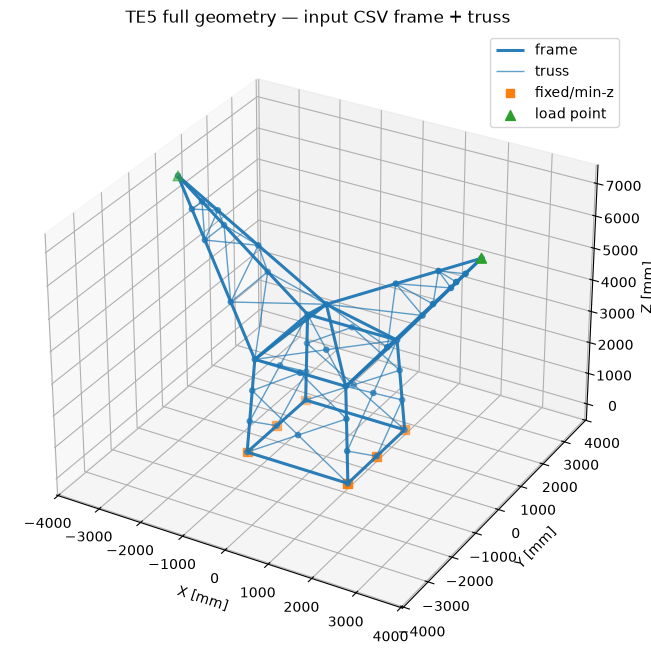

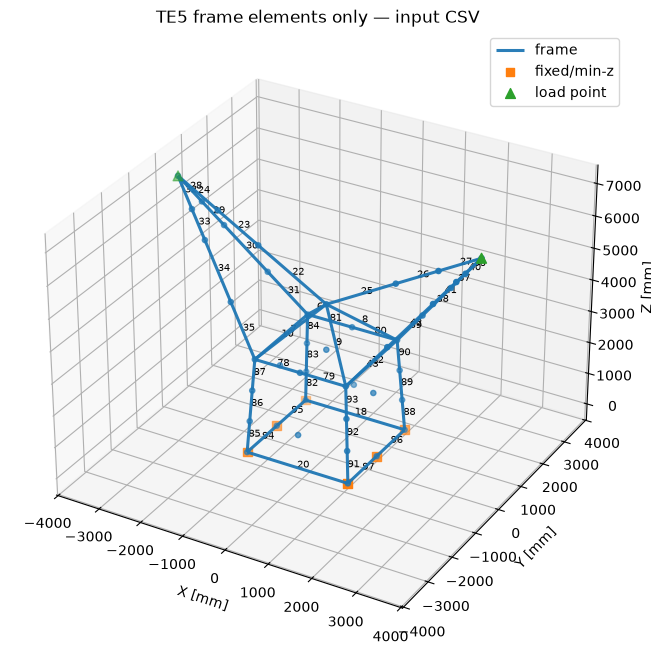

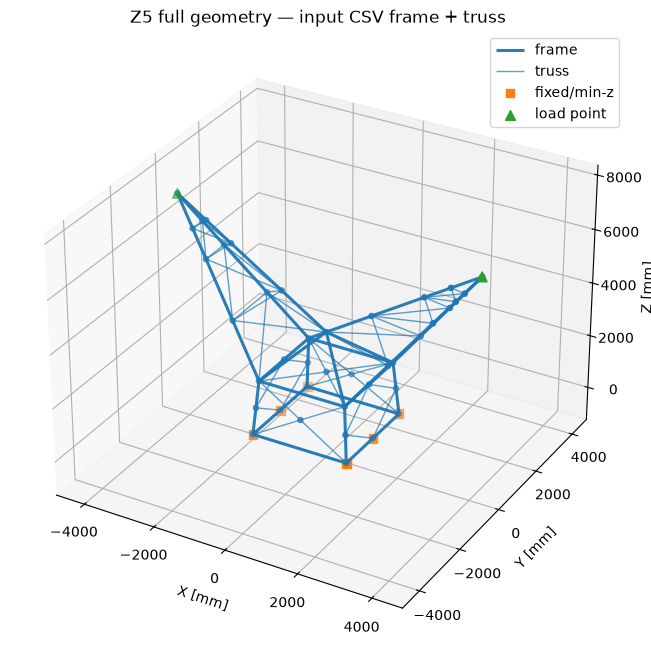

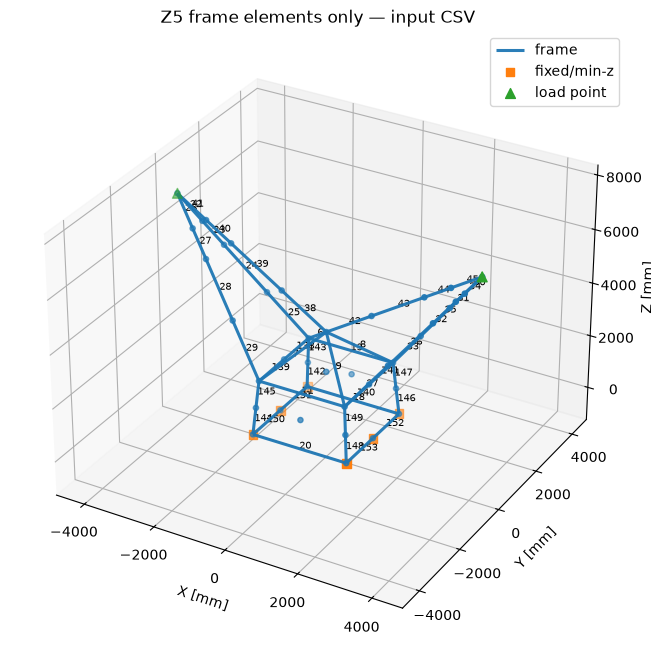

In [24]:
for name, model in models.items():
    fig, ax = plot_geometry(
        model.nodes, model.elements,
        title=f'{name} full geometry — input CSV frame + truss',
        annotate=False, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()

    fig, ax = plot_geometry(
        model.nodes, model.elements,
        title=f'{name} frame elements only — input CSV',
        annotate=False, annotate_elements=True, show_frame=True, show_truss=False,
    )
    plt.show()


## Solve with PyNite

In [25]:
pynite_options = PyNiteRunOptions(
    crossing_diagonal_mode=CROSSING_DIAGONAL_MODE,
    section_mode=SECTION_MODE,
    principal_orientation=PRINCIPAL_ORIENTATION,
)

pynite_results = {}
for name, model in models.items():
    print(f'Solving {name} with PyNite...')
    pynite_results[name] = analyze_pynite_model(
        model,
        LOAD_CASE_BY_LABEL,
        options=pynite_options,
        case_name='Main',
        combo_name='Main',
    )

pynite_summary = pd.DataFrame([summarize_pynite_result(res) for res in pynite_results.values()])
display(pynite_summary)


Solving TE5 with PyNite...


Solving Z5 with PyNite...


,model,backend,nodes,elements,frame_elements,truss_like_members,max_translation_mm,max_abs_Uz_mm,max_abs_axial_force_kN,max_bending_resultant_kNmm,max_sigma_MPa
0,TE5,PyNite,39,100,50,50,1.965847,1.306416,18.277877,174.607073,25.656518
1,Z5,PyNite,37,98,48,50,2.866584,1.799987,20.869697,227.474901,30.466840


## Optional direct comparison against the educational solver

This is useful for checking whether the two modelling paths are in the same broad range.

Expect differences. The two backends do not represent truss-like members and local axes in exactly the same way.


In [26]:
if RUN_INHOUSE_COMPARISON:
    inhouse_options = SolveOptions(
        crossing_diagonal_mode=CROSSING_DIAGONAL_MODE,
        section_mode=SECTION_MODE,
        principal_orientation=PRINCIPAL_ORIENTATION,
    )
    inhouse_results = {
        name: solve_model(model, LOAD_CASE_BY_LABEL, inhouse_options)
        for name, model in models.items()
    }
    inhouse_summary = pd.DataFrame([summarize_result(res) for res in inhouse_results.values()])
    inhouse_summary.insert(1, 'backend', 'in_house')

    common_cols = [c for c in pynite_summary.columns if c in inhouse_summary.columns]
    comparison = pd.concat([
        pynite_summary[common_cols],
        inhouse_summary[common_cols],
    ], ignore_index=True)
    display(comparison.sort_values(['model', 'backend']))
else:
    print('RUN_INHOUSE_COMPARISON = False')


,model,backend,nodes,elements,frame_elements,max_translation_mm,max_abs_Uz_mm,max_abs_axial_force_kN,max_bending_resultant_kNmm,max_sigma_MPa
0,TE5,PyNite,39,100,50,1.965847,1.306416,18.277877,174.607073,25.656518
2,TE5,in_house,39,100,50,1.965849,1.306417,18.277889,174.596789,27.391607
1,Z5,PyNite,37,98,48,2.866584,1.799987,20.869697,227.474901,30.466840
3,Z5,in_house,37,98,48,2.866587,1.799989,20.869703,227.459936,29.331158


## Result tables

In [27]:
DISPLAY_COLS = display_columns()

for name, res in pynite_results.items():
    print(f'Critical PyNite result rows for {name}')
    mf = res['member_forces'].sort_values('sigma_max_abs_MPa', ascending=False).head(TOP_N_CRITICAL)
    display(mf[[c for c in DISPLAY_COLS if c in mf.columns]])


Critical PyNite result rows for TE5


,element_id,element_type,start_label,end_label,member_role,section_name,axial_state,sigma_extreme_signed_MPa,sigma_max_abs_MPa,sigma_axial_signed_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm,stress_basis
15,29,frame,te5_e02_d4015_from_base,te5_e02_d3185_from_base,load_point_to_top,L90x90x7,compression,-25.656518,25.656518,-11.778421,-14263.668110,14263.668110,174604.567732,PyNite member sampling; axial+bending for fram...
23,37,frame,te5_e04_d4015_from_base,te5_e04_d3185_from_base,load_point_to_top,L90x90x7,compression,-25.656518,25.656518,-11.778421,-14263.668110,14263.668110,174604.567732,PyNite member sampling; axial+bending for fram...
22,36,frame,high_xpos,te5_e04_d4015_from_base,load_point_to_top,L90x90x7,compression,-25.633104,25.633104,-11.754478,-14234.672477,14234.672477,174607.073455,PyNite member sampling; axial+bending for fram...
14,28,frame,high_xneg,te5_e02_d4015_from_base,load_point_to_top,L90x90x7,compression,-25.633104,25.633104,-11.754478,-14234.672477,14234.672477,174607.073455,PyNite member sampling; axial+bending for fram...
9,23,frame,te5_e00_d2020_from_base,te5_e00_d3228_from_base,load_point_to_center,L90x90x7,tension,24.269000,24.269000,14.986211,18148.301655,18148.301655,105529.071962,PyNite member sampling; axial+bending for fram...
19,33,frame,te5_e03_d4015_from_base,te5_e03_d3185_from_base,load_point_to_top,L90x90x7,compression,-22.760981,22.760981,-11.597133,-14044.127497,14044.127497,136991.584836,PyNite member sampling; axial+bending for fram...
27,41,frame,te5_e05_d4015_from_base,te5_e05_d3185_from_base,load_point_to_top,L90x90x7,compression,-22.760981,22.760981,-11.597133,-14044.127497,14044.127497,136991.584836,PyNite member sampling; axial+bending for fram...
26,40,frame,high_xpos,te5_e05_d4015_from_base,load_point_to_top,L90x90x7,compression,-22.631368,22.631368,-11.466853,-13886.358975,13886.358975,137014.489718,PyNite member sampling; axial+bending for fram...
18,32,frame,high_xneg,te5_e03_d4015_from_base,load_point_to_top,L90x90x7,compression,-22.631368,22.631368,-11.466853,-13886.358975,13886.358975,137014.489718,PyNite member sampling; axial+bending for fram...
12,26,frame,te5_e01_d2020_from_base,te5_e01_d3228_from_base,load_point_to_center,L90x90x7,tension,22.111381,22.111381,14.986211,18148.301655,18148.301655,105529.071962,PyNite member sampling; axial+bending for fram...


Critical PyNite result rows for Z5


,element_id,element_type,start_label,end_label,member_role,section_name,axial_state,sigma_extreme_signed_MPa,sigma_max_abs_MPa,sigma_axial_signed_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm,stress_basis
26,40,frame,z5_e00_center_high_xneg_d3530,z5_e00_center_high_xneg_d4460,load_point_to_center,L102x102x6.4,tension,30.466840,30.466840,15.219098,19246.680646,19246.680646,215099.358423,PyNite member sampling; axial+bending for fram...
9,23,frame,z5_e02_top_xneg_ypos_d4906,z5_e02_top_xneg_ypos_d3918,load_point_to_top,L102x102x6.4,compression,-27.495526,27.495526,-12.554788,-15877.287238,15877.287238,227474.900503,PyNite member sampling; axial+bending for fram...
17,31,frame,z5_e04_top_xpos_ypos_d4906,z5_e04_top_xpos_ypos_d3918,load_point_to_top,L102x102x6.4,compression,-27.495526,27.495526,-12.554788,-15877.287238,15877.287238,227474.900503,PyNite member sampling; axial+bending for fram...
31,45,frame,z5_e01_center_high_xpos_d4460,high_xpos,load_point_to_center,L102x102x6.4,tension,27.270304,27.270304,15.238231,19270.877030,19270.877030,215092.482632,PyNite member sampling; axial+bending for fram...
27,41,frame,z5_e00_center_high_xneg_d4460,high_xneg,load_point_to_center,L102x102x6.4,tension,27.270304,27.270304,15.238231,19270.877030,19270.877030,215092.482632,PyNite member sampling; axial+bending for fram...
30,44,frame,z5_e01_center_high_xpos_d3530,z5_e01_center_high_xpos_d4460,load_point_to_center,L102x102x6.4,tension,27.249703,27.249703,15.219098,19246.680646,19246.680646,215100.084385,PyNite member sampling; axial+bending for fram...
8,22,frame,high_xneg,z5_e02_top_xneg_ypos_d4906,load_point_to_top,L102x102x6.4,compression,-27.071103,27.071103,-12.130655,-15340.911939,15340.911939,227470.426739,PyNite member sampling; axial+bending for fram...
16,30,frame,high_xpos,z5_e04_top_xpos_ypos_d4906,load_point_to_top,L102x102x6.4,compression,-27.071103,27.071103,-12.130655,-15340.911939,15340.911939,227470.426739,PyNite member sampling; axial+bending for fram...
21,35,frame,z5_e05_top_xpos_yneg_d4906,z5_e05_top_xpos_yneg_d3918,load_point_to_top,L102x102x6.4,compression,-24.379927,24.379927,-12.336137,-15600.771909,15600.771909,179275.492420,PyNite member sampling; axial+bending for fram...
13,27,frame,z5_e03_top_xneg_yneg_d4906,z5_e03_top_xneg_yneg_d3918,load_point_to_top,L102x102x6.4,compression,-24.379927,24.379927,-12.336137,-15600.771909,15600.771909,179275.492420,PyNite member sampling; axial+bending for fram...


## Absolute stress visualization

This uses the standard matplotlib helper and the PyNite-derived result table.


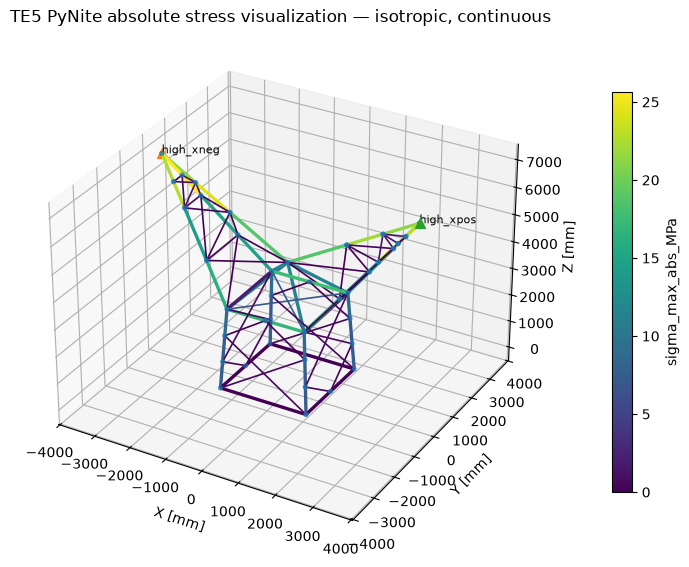

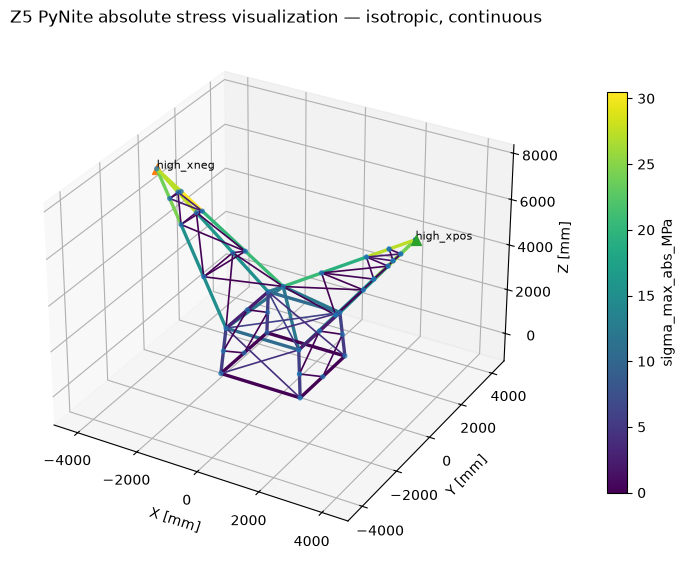

In [28]:
for name, res in pynite_results.items():
    fig, ax = plot_stress_3d(
        res['nodes'], res['elements'], res['member_forces'],
        title=f'{name} PyNite absolute stress visualization — {SECTION_MODE}, {CROSSING_DIAGONAL_MODE}',
        annotate_load_points=True, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()


## Signed tension/compression visualization

Positive values are tensile; negative values are compressive.


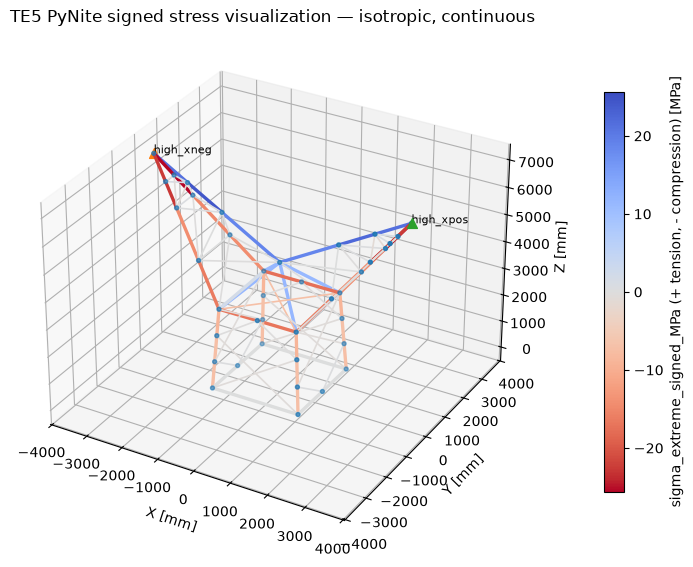

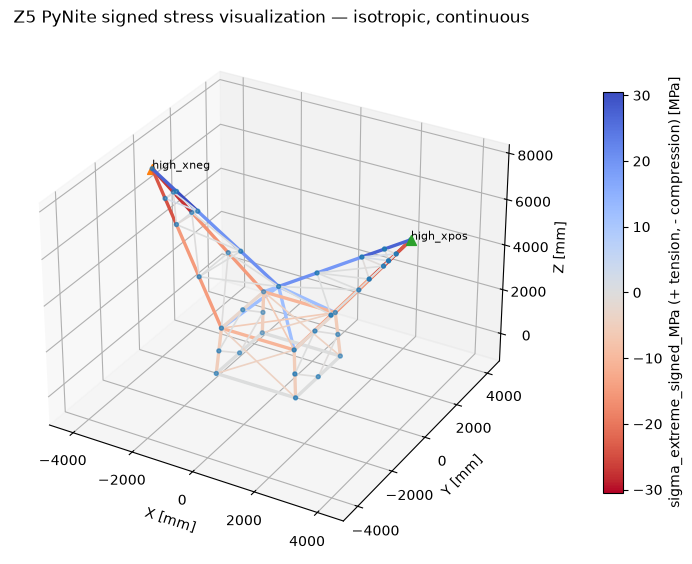

In [29]:
for name, res in pynite_results.items():
    fig, ax = plot_signed_stress_3d(
        res['nodes'], res['elements'], res['member_forces'],
        title=f'{name} PyNite signed stress visualization — {SECTION_MODE}, {CROSSING_DIAGONAL_MODE}',
        stress_column='sigma_extreme_signed_MPa',
        annotate_load_points=True, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()


## Deformed shape

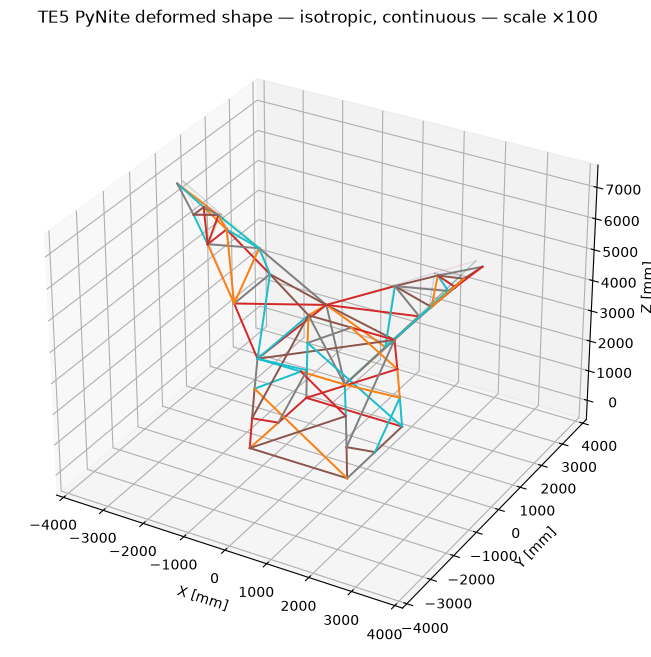

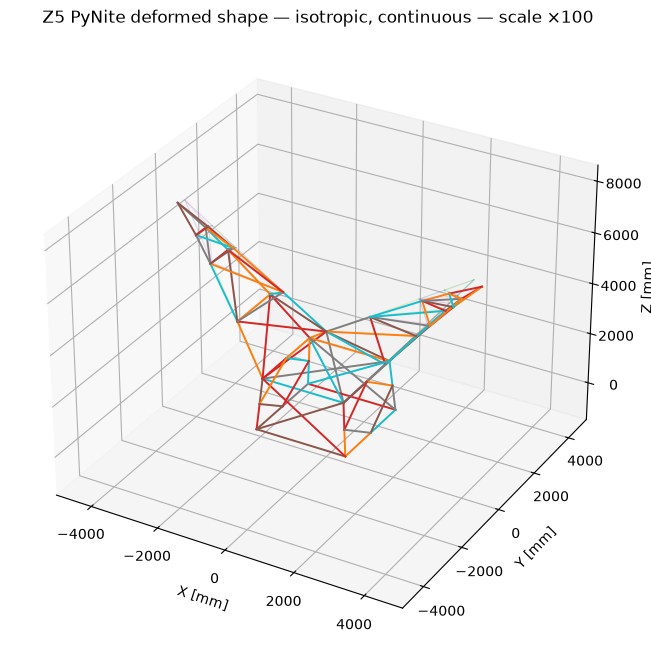

In [30]:
for name, res in pynite_results.items():
    fig, ax = plot_deformed_shape(
        res['nodes'], res['elements'], res['displacements'],
        scale=DEFORMED_SHAPE_SCALE,
        title=f'{name} PyNite deformed shape — {SECTION_MODE}, {CROSSING_DIAGONAL_MODE}',
        show_truss=True,
    )
    plt.show()


## Optional grouped XLSX export

In [31]:
if REPORTING_AVAILABLE:
    enriched = enrich_results_for_reporting(pynite_results)
    print('Region summary:')
    display(region_summary_table(enriched))
    print('Physical members:')
    display(physical_member_summary_table(enriched).head(40))

    out_xlsx = RESULTS_DIR / f'pynite_results_{SECTION_MODE}_{CROSSING_DIAGONAL_MODE}.xlsx'
    export_grouped_results_to_excel(enriched, out_xlsx, top_n=TOP_N_CRITICAL)
    print('Wrote:', out_xlsx)
else:
    print('reporting.py could not be imported:', REPORTING_IMPORT_ERROR)


Region summary:


,model,region,subregion,element_count,frame_count,truss_count,max_sigma_MPa,critical_element_id,critical_physical_member_id,max_abs_axial_force_kN,most_compressive_force_kN,most_compressive_element_id,largest_tensile_force_kN,largest_tensile_element_id,max_bending_resultant_kNmm
0,TE5,horn_xneg,horn_frame_center_to_load,1,1,0,21.295784,24,F_parent_000,17.163028,17.163028,24,17.163028,24,1.055256e+02
1,TE5,horn_xneg,horn_frame_load_to_top,4,4,0,25.633104,28,F_parent_002,14.595968,-14.595968,35,-13.886359,32,1.746071e+02
2,TE5,horn_xneg,horn_truss,1,0,1,0.034429,73,T_element_073,0.013221,-0.013221,73,-0.013221,73,1.088371e-15
3,TE5,horn_xpos,horn_frame_center_to_load,1,1,0,21.295784,27,F_parent_001,17.163028,17.163028,27,17.163028,27,1.055256e+02
4,TE5,horn_xpos,horn_frame_load_to_top,4,4,0,25.633104,36,F_parent_004,14.595968,-14.595968,43,-13.886359,40,1.746071e+02
5,TE5,horn_xpos,horn_truss,1,0,1,0.034429,57,T_element_057,0.013221,-0.013221,57,-0.013221,57,0.000000e+00
6,TE5,top_square,planar_diagonal_truss,2,0,2,7.093169,77,T_element_077,2.440050,-2.440050,77,-2.440050,76,3.055116e-16
7,TE5,top_square,square_frame,6,6,0,17.611305,81,F_parent_013,9.775344,-9.775344,81,0.672425,12,1.288409e+01
8,TE5,legs_and_faces,center_to_top_frame,4,4,0,11.432347,9,F_parent_009,8.060860,8.054662,8,8.060860,9,5.621594e+01
9,TE5,legs_and_faces,face_truss,16,0,16,0.566275,113,T_element_113,0.262752,-0.262752,113,0.158574,106,2.828654e-15


Physical members:


,model,region,subregion,physical_member_id,element_type,member_role,section_name,sub_element_count,sub_element_ids,total_sub_element_length_mm,max_sigma_MPa,critical_element_id,max_bending_resultant_kNmm,max_bending_element_id,most_compressive_force_kN,most_compressive_element_id,largest_tensile_force_kN,largest_tensile_element_id
0,TE5,horn_xneg,horn_frame_load_to_top,F_parent_002,frame,load_point_to_top,L90x90x7,4,"28,29,30,31",4907.043407,25.656518,29,1.746071e+02,28,-14.596212,30,-14.234672,28
1,TE5,horn_xneg,horn_frame_load_to_top,F_parent_003,frame,load_point_to_top,L90x90x7,4,"32,33,34,35",4907.043407,22.760981,33,1.370145e+02,32,-14.595968,35,-13.886359,32
2,TE5,horn_xneg,horn_truss,T_element_073,truss,upper_truss,L50x50x4,1,73,2337.350957,0.034429,73,1.088371e-15,73,-0.013221,73,-0.013221,73
3,TE5,horn_xpos,horn_frame_load_to_top,F_parent_004,frame,load_point_to_top,L90x90x7,4,"36,37,38,39",4907.043407,25.656518,37,1.746071e+02,36,-14.596212,38,-14.234672,36
4,TE5,horn_xpos,horn_frame_load_to_top,F_parent_005,frame,load_point_to_top,L90x90x7,4,"40,41,42,43",4907.043407,22.760981,41,1.370145e+02,40,-14.595968,43,-13.886359,40
5,TE5,horn_xpos,horn_truss,T_element_057,truss,upper_truss,L50x50x4,1,57,2337.350957,0.034429,57,0.000000e+00,57,-0.013221,57,-0.013221,57
6,TE5,top_square,planar_diagonal_truss,T_element_076,truss,top_square_diagonal,L45x45x4,1,76,3012.274888,7.093169,76,3.055116e-16,76,-2.440050,76,-2.440050,76
7,TE5,top_square,planar_diagonal_truss,T_element_077,truss,top_square_diagonal,L45x45x4,1,77,3012.274888,7.093169,77,3.055116e-16,77,-2.440050,77,-2.440050,77
8,TE5,top_square,square_frame,F_parent_010,frame,top_square_y_side,L80x80x5,1,10,2130.000000,1.964944,10,7.223471e+00,10,0.672425,10,0.672425,10
9,TE5,top_square,square_frame,F_parent_011,frame,top_square_x_side,L76x64x4.8,2,"78,79",2130.000000,16.960499,79,1.020784e+01,79,-9.763523,79,-9.763523,78


Wrote: /workspaces/keratia/results/pynite_results_isotropic_continuous.xlsx


# Z5 three-case PyNite study

The remaining cells run the three specific Z5 cases using the PyNite backend.


In [ ]:
Z5_CASES = {
    'Case_1': [
        {'node_label': 'high_xneg', 'Fx': 16250.0, 'Fy': 8320.0, 'Fz': -20000.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
        {'node_label': 'high_xpos', 'Fx': 16250.0, 'Fy': 8320.0, 'Fz': -20000.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
    ],
    'Case_2': [
        {'node_label': 'high_xneg', 'Fx': 48900.0, 'Fy': 0.0, 'Fz': -13400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
        {'node_label': 'high_xpos', 'Fx': 48900.0, 'Fy': 0.0, 'Fz': -13400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
    ],
    'Case_3': [
        {'node_label': 'high_xneg', 'Fx': 21600.0, 'Fy': 38000.0, 'Fz': -13400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
        {'node_label': 'high_xpos', 'Fx': 21600.0, 'Fy': 38000.0, 'Fz': -13400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
    ],
}


In [33]:
z5_pynite_case_results = {}
for case_name, loads in Z5_CASES.items():
    print(f'Solving Z5 {case_name} with PyNite...')
    z5_pynite_case_results[case_name] = analyze_pynite_model(
        models['Z5'],
        loads,
        options=pynite_options,
        case_name=case_name,
        combo_name=case_name,
    )

z5_pynite_summary = pd.DataFrame([
    {'case': case_name, **summarize_pynite_result(res)}
    for case_name, res in z5_pynite_case_results.items()
])
display(z5_pynite_summary)


Solving Z5 Case_1 with PyNite...
Solving Z5 Case_2 with PyNite...
Solving Z5 Case_3 with PyNite...


,case,model,backend,nodes,elements,frame_elements,truss_like_members,max_translation_mm,max_abs_Uz_mm,max_abs_axial_force_kN,max_bending_resultant_kNmm,max_sigma_MPa
0,Case_1,Z5,PyNite,37,98,48,50,10.947312,6.356887,74.324058,700.842022,94.498876
1,Case_2,Z5,PyNite,37,98,48,50,22.943335,12.843463,150.793943,1350.981831,186.682567
2,Case_3,Z5,PyNite,37,98,48,50,18.316278,6.699674,150.498690,1026.058718,180.137014


## Z5 PyNite case visualizations

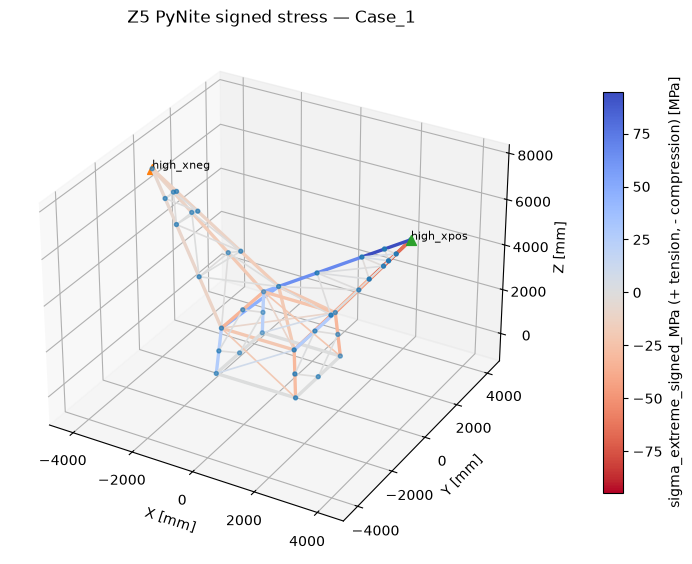

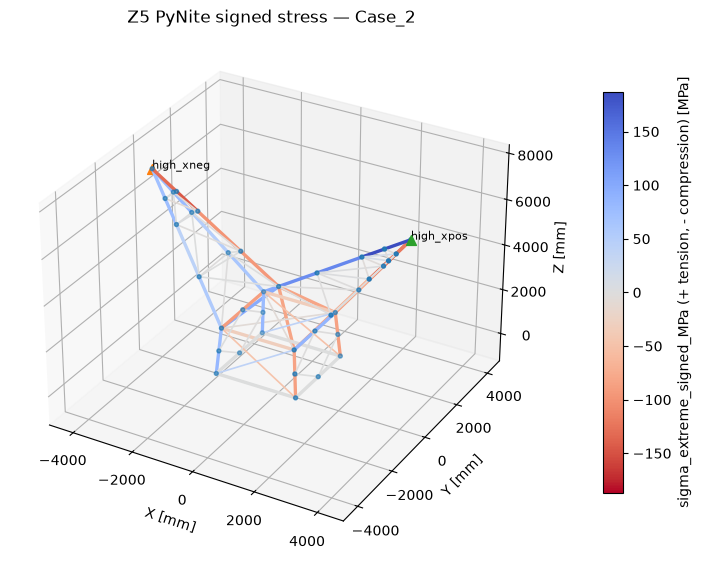

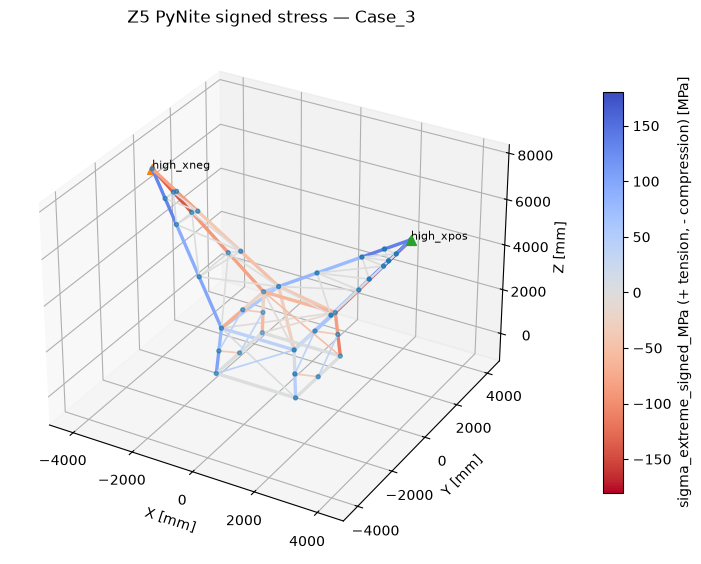

In [34]:
for case_name, res in z5_pynite_case_results.items():
    fig, ax = plot_signed_stress_3d(
        res['nodes'], res['elements'], res['member_forces'],
        title=f'Z5 PyNite signed stress — {case_name}',
        stress_column='sigma_extreme_signed_MPa',
        annotate_load_points=True, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()

    # fig, ax = plot_deformed_shape(
    #     res['nodes'], res['elements'], res['displacements'],
    #     scale=DEFORMED_SHAPE_SCALE,
    #     title=f'Z5 PyNite deformed shape — {case_name}',
    #     show_truss=True,
    # )
    # plt.show()


## Z5 Case 1 exceedance check under PyNite

This reproduces the earlier envelope question for the PyNite backend: where does Case 1 exceed Case 2 and/or Case 3?


In [35]:
def case1_exceedance_table(case_results):
    metrics = [
        'sigma_max_abs_MPa',
        'max_abs_N_N',
        'sigma_axial_signed_MPa',
        'max_M_resultant_Nmm',
    ]
    base = case_results['Case_1']['member_forces'].copy()
    out_rows = []
    for metric in metrics:
        c1 = base[['element_id', 'start_label', 'end_label', 'member_role', 'section_name', metric]].rename(columns={metric: 'Case_1'})
        c2 = case_results['Case_2']['member_forces'][['element_id', metric]].rename(columns={metric: 'Case_2'})
        c3 = case_results['Case_3']['member_forces'][['element_id', metric]].rename(columns={metric: 'Case_3'})
        merged = c1.merge(c2, on='element_id').merge(c3, on='element_id')
        for _, row in merged.iterrows():
            for other in ['Case_2', 'Case_3']:
                diff = float(row['Case_1'] - row[other])
                if diff > 0:
                    pct = diff / abs(float(row[other])) * 100.0 if abs(float(row[other])) > 1e-12 else float('inf')
                    out_rows.append({
                        'metric': metric,
                        'element_id': int(row['element_id']),
                        'start_label': row['start_label'],
                        'end_label': row['end_label'],
                        'member_role': row['member_role'],
                        'section_name': row['section_name'],
                        'comparison': f'Case_1 > {other}',
                        'Case_1': float(row['Case_1']),
                        other: float(row[other]),
                        'absolute_increase': diff,
                        'percent_increase': pct,
                    })
    return pd.DataFrame(out_rows).sort_values(['metric', 'element_id', 'comparison']).reset_index(drop=True)

z5_case1_exceedances = case1_exceedance_table(z5_pynite_case_results)
display(z5_case1_exceedances)


,metric,element_id,start_label,end_label,member_role,section_name,comparison,Case_1,Case_3,absolute_increase,percent_increase,Case_2
0,max_M_resultant_Nmm,6,center,top_xneg_ypos,center_to_top,L102x102x6.4,Case_1 > Case_3,1.374013e+05,5.574286e+04,8.165849e+04,146.491376,NaN
1,max_M_resultant_Nmm,9,center,top_xpos_yneg,center_to_top,L102x102x6.4,Case_1 > Case_3,9.815246e+04,6.875443e+04,2.939804e+04,42.758026,NaN
2,max_M_resultant_Nmm,25,z5_e02_top_xneg_ypos_d1942,top_xneg_ypos,load_point_to_top,L102x102x6.4,Case_1 > Case_3,1.593843e+05,1.370717e+05,2.231265e+04,16.278094,NaN
3,max_M_resultant_Nmm,37,z5_e05_top_xpos_yneg_d1942,top_xpos_yneg,load_point_to_top,L102x102x6.4,Case_1 > Case_3,1.708100e+05,1.598996e+05,1.091039e+04,6.823277,NaN
4,max_M_resultant_Nmm,114,z5_e05_top_xpos_yneg_d1942,z5_e01_center_high_xpos_d1650,inserted_center_beam_truss_xpos,L50x50x4,Case_1 > Case_3,2.895606e-11,1.808885e-11,1.086721e-11,60.076808,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
146,sigma_max_abs_MPa,160,z5_e16_mid,z5_e21_mid,lower_face_inscribed_xpos_bottom,L55x55x4,Case_1 > Case_2,5.040548e-01,NaN,2.013085e-01,66.494091,0.302746
147,sigma_max_abs_MPa,161,z5_e17_mid,z5_e21_mid,lower_face_inscribed_xpos_bottom,L55x55x4,Case_1 > Case_2,1.082442e+00,NaN,8.121453e-01,300.463840,0.270297
148,sigma_max_abs_MPa,162,z5_e10_mid,z5_e14_mid,lower_face_inscribed_xneg_top,L60x60x4,Case_1 > Case_2,9.482789e-01,NaN,8.373149e-01,754.582484,0.110964
149,sigma_max_abs_MPa,163,z5_e10_mid,z5_e15_mid,lower_face_inscribed_xneg_top,L60x60x4,Case_1 > Case_2,9.353678e-01,NaN,7.867130e-01,529.221341,0.148655


In [36]:
out_dir = RESULTS_DIR / 'pynite_z5_three_cases'
out_dir.mkdir(exist_ok=True)

z5_pynite_summary.to_csv(out_dir / 'summary.csv', index=False)
z5_case1_exceedances.to_csv(out_dir / 'case1_element_exceedances.csv', index=False)

for case_name, res in z5_pynite_case_results.items():
    res['displacements'].to_csv(out_dir / f'{case_name}_displacements.csv', index=False)
    res['member_forces'].to_csv(out_dir / f'{case_name}_member_forces.csv', index=False)
    res['reactions'].to_csv(out_dir / f'{case_name}_reactions.csv', index=False)

print('Wrote:', out_dir)


Wrote: /workspaces/keratia/results/pynite_z5_three_cases
